In [2]:
import pandas as pd

import matplotlib.pyplot as plt


from pathlib import Path 

import numpy as np 

In [3]:
name_map = {
    "aug_cnn_4l_short_input_edt": "Baseline",
    "aug_cnn_4l_short_input_edt_fp_strict_done_nov": "Verified FPs",
    "aug_cnn_4l_short_input_edt_fp_done_nov": "All FPs",
    "aug_cnn_4l_short_input_edt_fp_strict_aneu_nov": "Verified FPs + Extra aneurysms",
    "aug_cnn_4l_short_input_edt_fp_strict_aneu_done_nov": "All FPs + Extra aneurysms",

}

In [10]:
to_compare = [
        [
        #"aug_cnn_4l_short_input_edt",
        #"aug_cnn_4l_short_input_edt_lon",
        #"aug_cnn_4l_short_input_edt_fp_strict_done_nov",
        #"aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon_100",
        #"aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon_200",
        #"aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon_300",
        "aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon",
        #"aug_cnn_4l_short_input_edt_fp_done_nov",
        #"aug_cnn_4l_short_input_edt_fp_done_nov_lon",
        #"aug_cnn_4l_short_input_edt_fp_strict_aneu_done_nov",
        "aug_cnn_4l_short_input_edt_fp_strict_aneu_done_nov_lon",
        #"aug_cnn_4l_short_input_edt_fp_aneu_done_nov",
        #"aug_cnn_4l_short_input_edt_fp_aneu_done_nov_lon",
        
    ],
        [
        "aug_cnn_4l_short_input_edt",
        "aug_cnn_4l_short_input_edt_rsna",
        "aug_cnn_4l_short_input_edt_merged",
        "aug_cnn_4l_short_input_edt_fp_strict_done_merged",
        "aug_cnn_4l_short_input_edt_fp_done_merged",
        "aug_cnn_4l_short_input_edt_fp_strict_aneu_done_merged",
        "aug_cnn_4l_short_input_edt_fp_aneu_done_merged"  
    ],

]
path_results = Path("../results")
datasets = ["hospital140", "cmha", "internal_test", "external"]


ious = [0.1, 0.2, 0.3]

modes = ["mode_base", "mode_1", "mode_3", "mode_5"]

comp = 0


stats = []
pair = to_compare[comp]

columns = [
    "dataset",
    "model",
    "chkpt",
    "iou",
    "mode",
    "se_0.1",
    "se_0.2",
    "se_0.5",
    "se_1.0",
    "se_2.0",
    "se_4.0",
    "se_8.0",
]

for dataset in datasets:
    for model in pair:
        file_chkpts = path_results / dataset / model
        # get all subfolders with the word "inf"
        subfolders = [
            str(file.name)
            for file in file_chkpts.iterdir()
            if file.is_dir() and "inf" in file.name
        ]
        for inf in subfolders:
            inf_append = inf.replace("inference_", "")
            for iou in ious:
                for mode in modes:
                    path_csv_file = (
                        file_chkpts / f"{mode}/iou{iou}_froc_{inf_append}/froc.csv"
                    )
                    try:
                        df_froc = pd.read_csv(path_csv_file)
                    except:
                        print(f"File not found: {path_csv_file}")
                        continue
                    # print(path_csv_file)
                    sensitivities = df_froc.iloc[0, 1:].values.tolist()
                    stats.append(
                        [
                            dataset,
                            model,
                            inf_append,
                            iou,
                            mode,
                            *sensitivities,
                        ]
                    )

In [11]:
df_results = pd.DataFrame(stats, columns=columns)

aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon hospital140 mode_1 0.2 final
aug_cnn_4l_short_input_edt_fp_strict_aneu_done_nov_lon hospital140 mode_1 0.2 final
aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon cmha mode_1 0.2 final
aug_cnn_4l_short_input_edt_fp_strict_aneu_done_nov_lon cmha mode_1 0.2 final
aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon internal_test mode_1 0.2 final
aug_cnn_4l_short_input_edt_fp_strict_aneu_done_nov_lon internal_test mode_1 0.2 final
aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon external mode_1 0.2 final
aug_cnn_4l_short_input_edt_fp_strict_aneu_done_nov_lon external mode_1 0.2 final


Text(0.5, 0.98, 'FROC Curves Comparison, IoU 0.2, Checkpoint: final, Mode: mode_1')

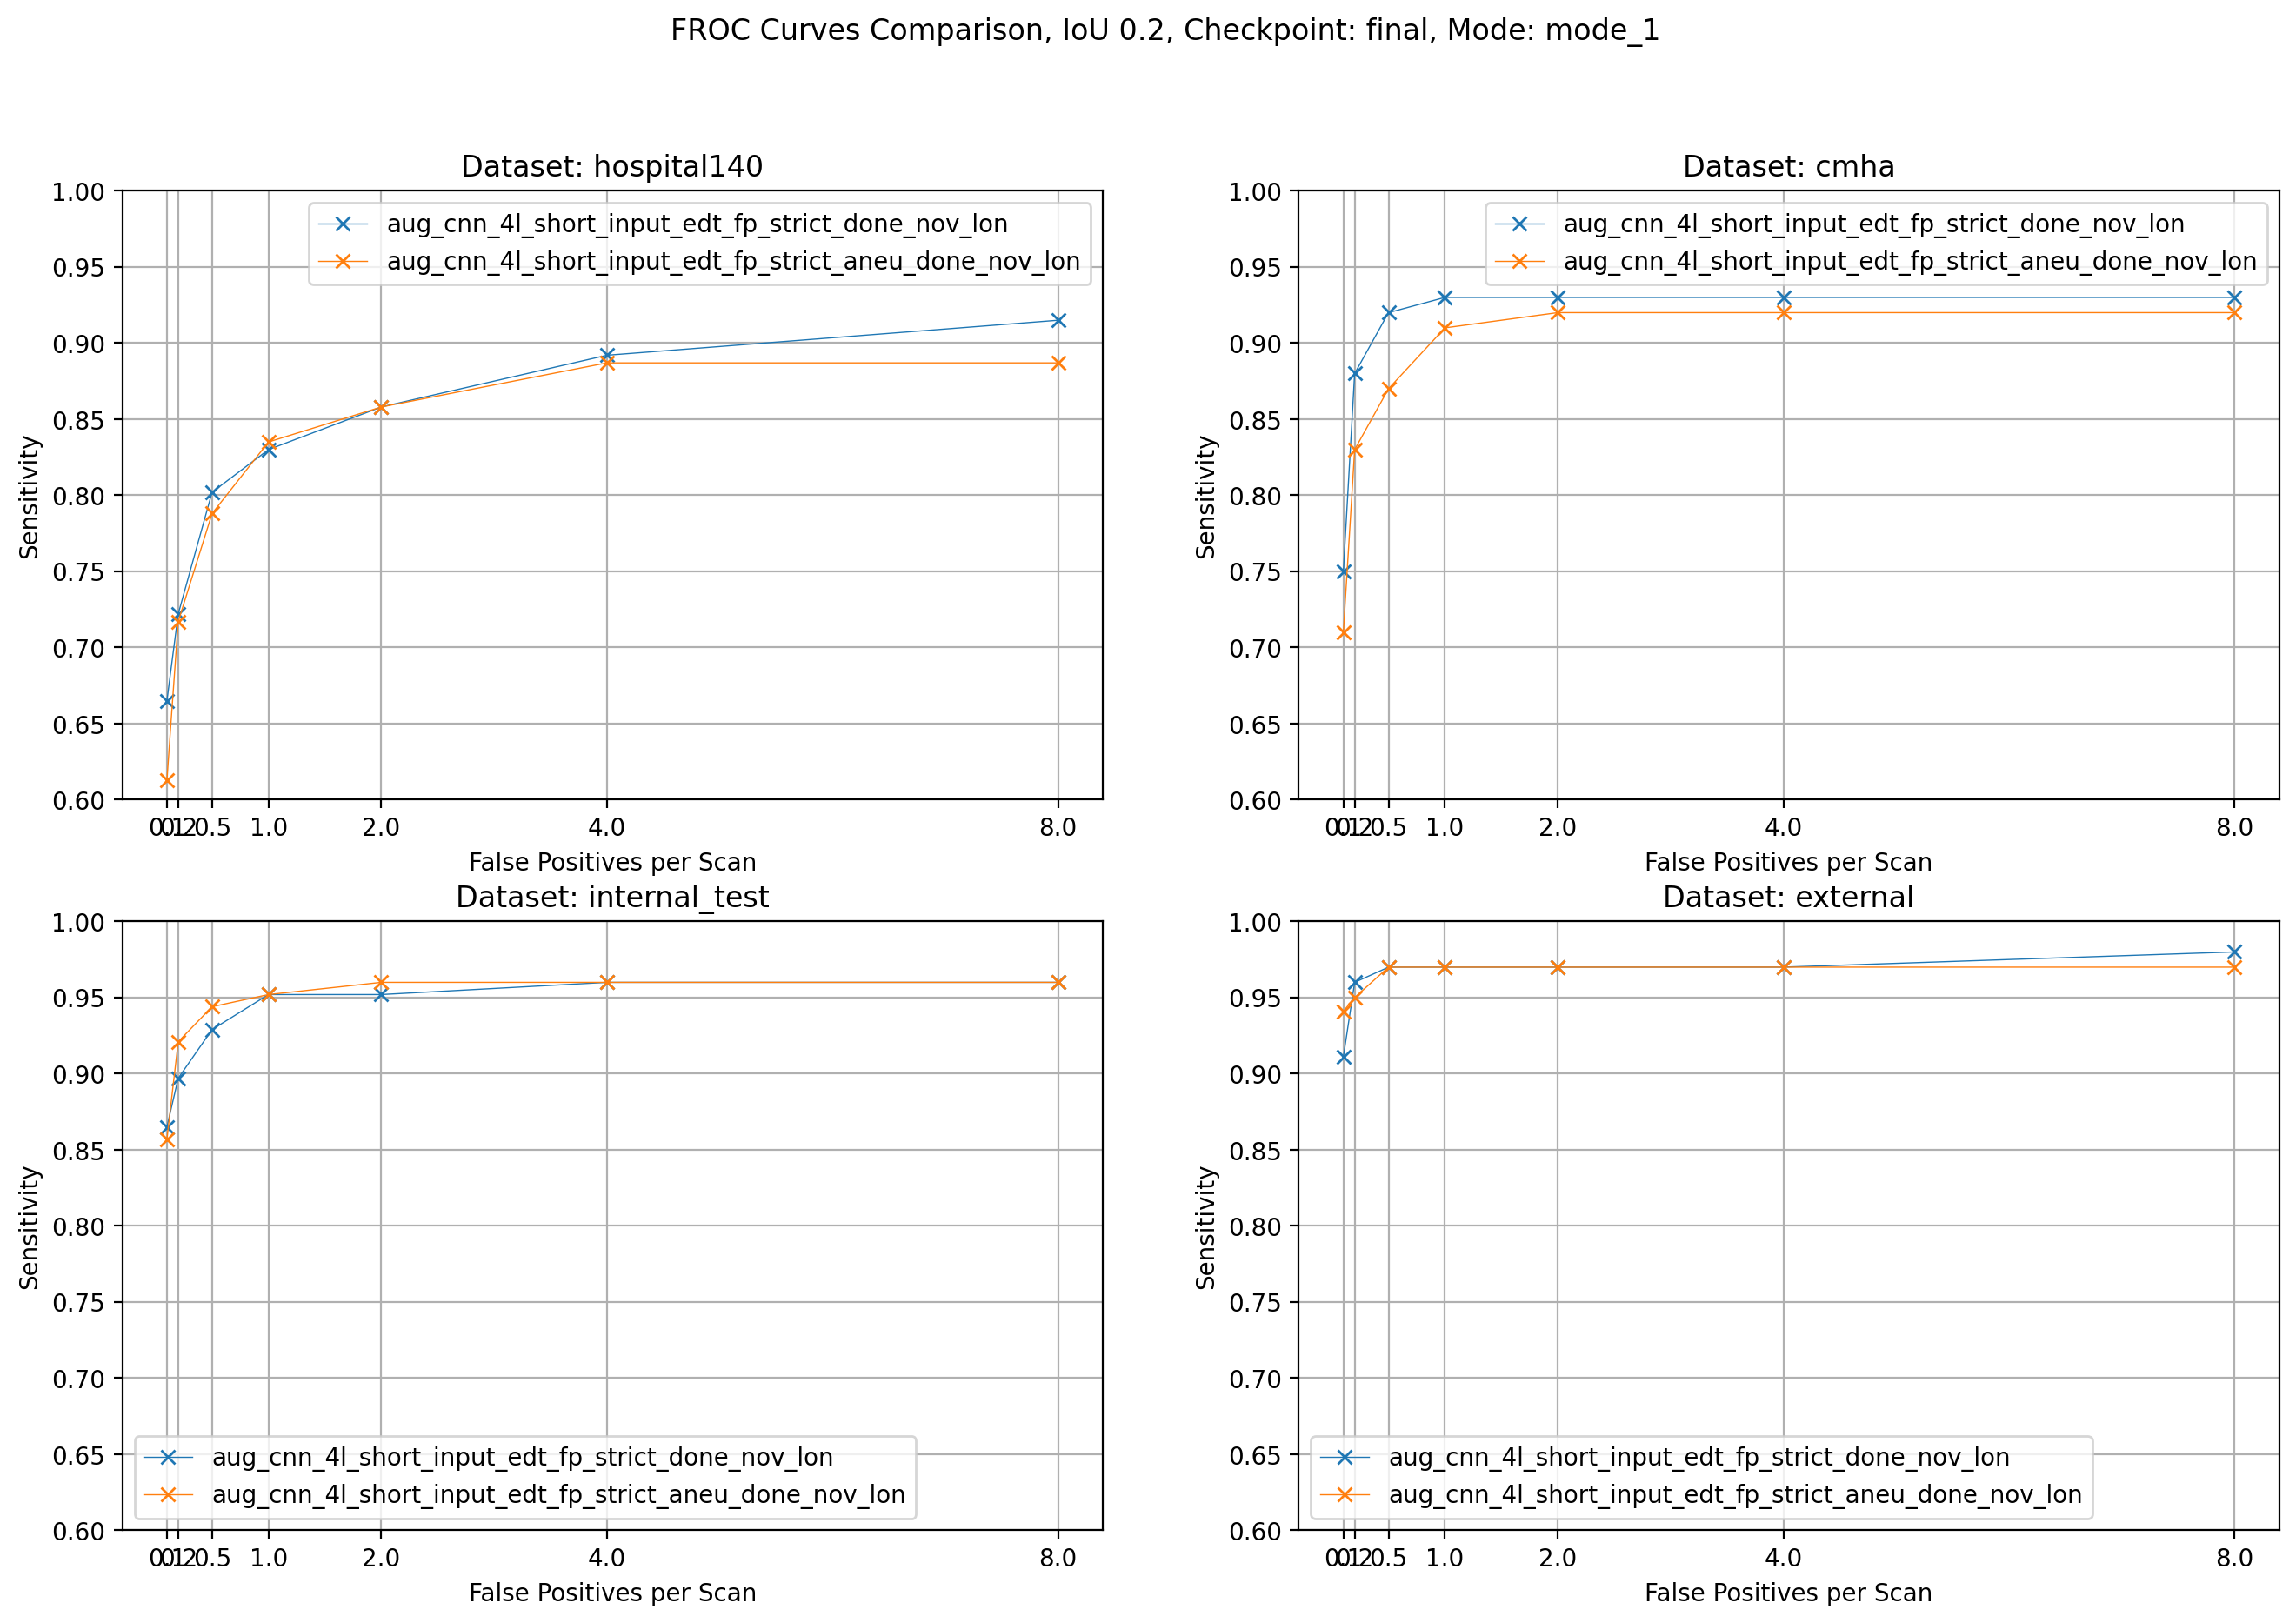

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(16, 10), dpi=200)

datasets = ["hospital140", "cmha", "internal_test", "external"]
mode = "mode_1"
iou = 0.2
chkpt = "final"

for i, dataset in enumerate(datasets):
    ax_i = ax[i // 2, i % 2]
    for model in pair:
        print(model, dataset, mode, iou, chkpt)
        df_plot = df_results[
            (df_results["dataset"] == dataset)
            & (df_results["mode"] == mode)
            & (df_results["iou"] == iou)
            & (df_results["chkpt"] == chkpt)
            & (df_results["model"] == model)
        ]
        fp_per_scan = [0.1, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0]

        sensitivities = df_plot.iloc[0, 5:].values.tolist()
        ax_i.plot(
            fp_per_scan,
            sensitivities,
            marker="x",
            linewidth=0.5,
            label=model,
        )
    ax_i.set_title(f"Dataset: {dataset}")
    ax_i.set_xlabel("False Positives per Scan")
    ax_i.set_ylabel("Sensitivity")
    ax_i.set_xticks(fp_per_scan)
    ax_i.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax_i.set_ylim(0.6, 1)
    # do log scale on the x axis
    

    ax_i.grid(True)
    ax_i.legend()
fig.suptitle(f"FROC Curves Comparison, IoU {iou}, Checkpoint: {chkpt}, Mode: {mode}")

In [13]:
models = to_compare[1]

In [23]:
iou_val = 0.2
seatfpval = 0.5

for i, model in enumerate(models):
    sensitivity = df_results[
        (df_results["model"] == model)
        & (df_results["iou"] == iou_val)
        & (df_results["chkpt"] == "final")
        & (df_results["mode"] == "mode_1")
    ]
    print(f"Model {i+1}: {model}")
    print(sensitivity[["dataset","chkpt","iou","mode","se_0.5"]])
    print("\n\n")

Model 1: aug_cnn_4l_short_input_edt
            dataset  chkpt  iou    mode  se_0.5
77      hospital140  final  0.2  mode_1   0.755
557            cmha  final  0.2  mode_1   0.880
1121  internal_test  final  0.2  mode_1   0.913
1685       external  final  0.2  mode_1   0.970



Model 2: aug_cnn_4l_short_input_edt_rsna
            dataset  chkpt  iou    mode  se_0.5
149     hospital140  final  0.2  mode_1   0.807
629            cmha  final  0.2  mode_1   0.890
1193  internal_test  final  0.2  mode_1   0.929
1757       external  final  0.2  mode_1   0.960



Model 3: aug_cnn_4l_short_input_edt_merged
            dataset  chkpt  iou    mode  se_0.5
233     hospital140  final  0.2  mode_1   0.825
761            cmha  final  0.2  mode_1   0.870
1325  internal_test  final  0.2  mode_1   0.929
1889       external  final  0.2  mode_1   0.970



Model 4: aug_cnn_4l_short_input_edt_fp_strict_done_merged
            dataset  chkpt  iou    mode  se_0.5
281     hospital140  final  0.2  mode_1   0.8

In [16]:
sensitivity[["model","dataset","chkpt","iou","mode","se_0.5"]]

,model,dataset,chkpt,iou,mode,se_0.5


In [9]:
iou_val = 0.2
seatfpval = 0.5

model = "aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon" 

sensitivity = df_results[
    (df_results["model"] == model)
    & (df_results["iou"] == iou_val)
    & (df_results["chkpt"] == "final")
    & (df_results["mode"] == "mode_1")
]

sensitivity[["model","dataset","chkpt","iou","mode","se_0.5"]]

,model,dataset,chkpt,iou,mode,se_0.5
485,aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon,hospital140,final,0.2,mode_1,0.802
1457,aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon,cmha,final,0.2,mode_1,0.920
2429,aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon,internal_test,final,0.2,mode_1,0.929
3341,aug_cnn_4l_short_input_edt_fp_strict_done_nov_lon,external,final,0.2,mode_1,0.970


In [1]:
import pandas  as pd

path_preds = "/projects/vig/alberto/medical/deform-aneurysm-detection/results/cta_rsna_ane/cpmnet/inference_50k/predict.csv"
df_preds = pd.read_csv(path_preds)

path_gt = "/projects/vig/alberto/medical/deform-aneurysm-detection/labels/gt/source_files_rsna/annotations_final.csv"

df_gt = pd.read_csv(path_gt)

In [ ]:
# only keep predictins with score > 0.8
print(len(df_preds))
df_preds = df_preds[df_preds["probability"] > 0.8]
print(len(df_preds))


16880
1391


In [3]:
df_preds

,seriesuid,probability,coordZ,coordY,coordX,d,h,w
20,1.2.826.0.1.3680043.8.498.10022796280698534221...,0.958824,153.044310,382.99326,224.197420,12.765799,12.784849,13.390894
60,1.2.826.0.1.3680043.8.498.10035643165968342618...,0.923883,135.629520,351.35620,342.011230,14.529717,15.073971,13.084855
61,1.2.826.0.1.3680043.8.498.10035643165968342618...,0.862204,218.018810,259.24010,288.854300,42.754383,18.857029,20.604210
80,1.2.826.0.1.3680043.8.498.10042474696169267476...,0.947208,118.286120,301.03668,262.436070,10.395800,12.303961,12.497678
81,1.2.826.0.1.3680043.8.498.10042474696169267476...,0.800081,204.122220,208.84767,269.301730,23.275568,20.388285,19.675385
...,...,...,...,...,...,...,...,...
16820,1.2.826.0.1.3680043.8.498.99887675554378211308...,0.918073,116.697266,209.78830,101.943985,16.676508,15.917547,18.937862
16821,1.2.826.0.1.3680043.8.498.99887675554378211308...,0.895545,138.019620,193.23073,132.104000,8.306266,8.813201,9.186226
16840,1.2.826.0.1.3680043.8.498.99892390884723813599...,0.864184,172.693700,293.62140,172.867890,10.874173,10.387160,11.600203
16841,1.2.826.0.1.3680043.8.498.99892390884723813599...,0.824235,198.316270,310.99026,356.872400,19.283323,19.604387,24.968908


In [7]:
# for each pred, check if it overlaps with any gt aneurysm with iou > 0.3, if not, mark it as false positive
#fields are coordZ, coordY, coordX, d, h, w
df_preds["is_fp"] = False
for index, pred in df_preds.iterrows():
    pred_box = [
        pred["coordZ"],
        pred["coordY"],
        pred["coordX"],
        pred["d"],
        pred["h"],
        pred["w"],
    ]
    # compute the box corners
    pred_min = [
        pred_box[0] - pred_box[3] / 2,
        pred_box[1] - pred_box[4] / 2,
        pred_box[2] - pred_box[5] / 2,
    ]
    pred_max = [
        pred_box[0] + pred_box[3] / 2,
        pred_box[1] + pred_box[4] / 2,
        pred_box[2] + pred_box[5] / 2,
    ]
    is_fp = True
    preds_scan = df_preds[df_preds["seriesuid"] == pred["seriesuid"]]
    gts_scan = df_gt[df_gt["seriesuid"] == pred["seriesuid"]]

    for gt_index, gt in gts_scan.iterrows():

        gt_box = [
            gt["coordZ"],
            gt["coordY"],
            gt["coordX"],
            gt["d"],
            gt["h"],
            gt["w"],
        ]
        gt_min = [
            gt_box[0] - gt_box[3] / 2,
            gt_box[1] - gt_box[4] / 2,
            gt_box[2] - gt_box[5] / 2,
        ]
        gt_max = [
            gt_box[0] + gt_box[3] / 2,
            gt_box[1] + gt_box[4] / 2,
            gt_box[2] + gt_box[5] / 2,
        ]
        # compute intersection
        inter_min = [
            max(pred_min[0], gt_min[0]),
            max(pred_min[1], gt_min[1]),
            max(pred_min[2], gt_min[2]),
        ]
        inter_max = [
            min(pred_max[0], gt_max[0]),
            min(pred_max[1], gt_max[1]),
            min(pred_max[2], gt_max[2]),
        ]
        inter_dims = [
            max(0, inter_max[0] - inter_min[0]),
            max(0, inter_max[1] - inter_min[1]),
            max(0, inter_max[2] - inter_min[2]),
        ]
        inter_volume = inter_dims[0] * inter_dims[1] * inter_dims[2]
        pred_volume = pred_box[3] * pred_box[4] * pred_box[5]
        gt_volume = gt_box[3] * gt_box[4] * gt_box[5]
        union_volume = pred_volume + gt_volume - inter_volume
        iou = inter_volume / union_volume if union_volume > 0 else 0
        if iou > 0.3:
            is_fp = False
            break
    if is_fp:
        df_preds.at[index, "is_fp"] = True
    else:
        df_preds.at[index, "is_fp"] = False
    
    

   


In [9]:
df_preds["is_fp"].value_counts()

is_fp
False    759
True     632
Name: count, dtype: int64

In [10]:
# write is_fp cases to csv
df_preds = df_preds[df_preds["is_fp"] == True]
df_preds.to_csv("fps_rsna.csv", index=False)